# Auto MPG
This is the second linear regression notebook I am making in my journey of learning Machine Learning

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("auto-mpg.csv", na_values='?')
df = df.dropna()
print(df.head())
print(df.dtypes)

    mpg  cylinders  displacement  horsepower  weight  acceleration  \
0  18.0          8         307.0       130.0    3504          12.0   
1  15.0          8         350.0       165.0    3693          11.5   
2  18.0          8         318.0       150.0    3436          11.0   
3  16.0          8         304.0       150.0    3433          12.0   
4  17.0          8         302.0       140.0    3449          10.5   

   model year  origin                   car name  
0          70       1  chevrolet chevelle malibu  
1          70       1          buick skylark 320  
2          70       1         plymouth satellite  
3          70       1              amc rebel sst  
4          70       1                ford torino  
mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight            int64
acceleration    float64
model year        int64
origin            int64
car name            str
dtype: object


Observations: There are 6 varaible to do the regression on (7 if we include the car name). For now lets begin by implementing the manual functions of the cost function and gradient descent and the algo for it. We wil also have to do some standardization. We will verify out results using skit-learn at the end. I added print(df.dtypes) later to find out that horsepower is a string. see below for the thought process and getting around this.

In [3]:
def compute_cost(x, y, w, b):
    m = x.shape[0]
    cost = 0
    for i in range(m):
        f = np.dot(w, x[i]) + b
        cost += (f-y[i])**2
    return cost * (1/(2*m))

In [4]:
def compute_gradient(x, y, w, b):
    m = x.shape[0]
    dj_dw = np.zeros(x.shape[1])
    dj_db = 0
    for i in range(m):
        f = np.dot(w, x[i]) + b
        dj_dw += (f-y[i])*x[i]
        dj_db += (f-y[i])
    return dj_dw * (1/m), dj_db * (1/m)

In [5]:
def gradient_descent_algo(x, y, w, b, learning_rate, num_iters):
    cost_values = []
    for i in range(num_iters):
        if i % 10 == 0:  # we take in the cost values every 10 iters instead of 100 like last time for a better cost graph
            cost_values.append(compute_cost(x, y, w, b))
        dw, db = compute_gradient(x, y, w, b)
        local_w = w - learning_rate * dw
        local_b = b - learning_rate * db
        w, b = local_w, local_b
    return w, b, cost_values

The 3 functions are completed, not lets make the main part, where we can use them.

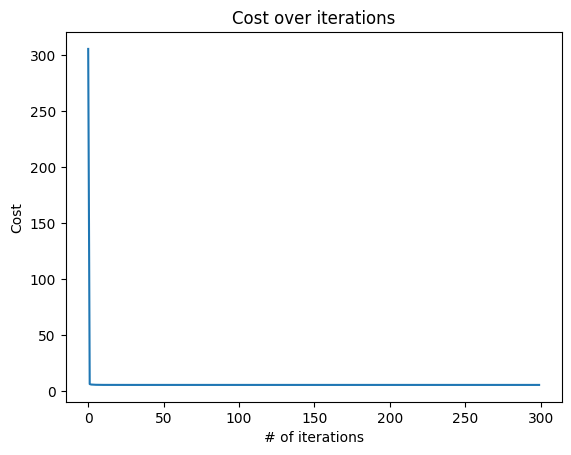

In [6]:
X = df[["cylinders",  "displacement", "horsepower",  "weight",  "acceleration", "model year"]].to_numpy()
X_std = (X - X.mean(axis=0)) / X.std(axis=0)
y = df["mpg"].to_numpy()
w_init = np.zeros(X_std.shape[1 ])

w_final, b_final, cost_values = gradient_descent_algo(X_std, y, w_init, 0, 0.3, 3000)

plt.plot(cost_values)
plt.xlabel("# of iterations")
plt.ylabel("Cost")
plt.title("Cost over iterations")
plt.show()

A bug appeared: horsepower is a string so we change it to ints in the code above. Upon futher inspection, it turns out that there are some '?' in the place of horsepower, so we have to ignore these. We use:
- df = pd.read_csv("auto-mpg.csv", na_values='?')
- df = df.dropna()

at the very top

After fixing the bug, the cost function looks fine now, we will nwo use scikit-learn to verify our regression and then print a final graph

In [7]:
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression

X_sklearn = X_std
model = LinearRegression()
model.fit(X_sklearn, y)

print("sklearn weight:", model.coef_)
print("sklearn bias:  ", model.intercept_)
print("your w_final:  ", w_final)
print("your b_final:  ", b_final)

sklearn weight: [-0.56194996  0.80247616 -0.0150445  -5.76399971  0.23495704  2.77166415]
sklearn bias:   23.44591836734694
your w_final:   [-0.56194996  0.80247616 -0.0150445  -5.76399971  0.23495704  2.77166415]
your b_final:   23.445918367346938


The first set of weights I got were:

- sklearn weight: [-0.56194996  0.80247616 -0.0150445  -5.76399971  0.23495704  2.77166415]
- sklearn bias:   23.44591836734694
- your w_final:   [-0.36722126  0.09468196 -0.30206678 -5.09367229  0.03351437  2.72061026]
- your b_final:   23.445918367345552

I will increase the learning rate to 0.1 to see if that fixes the mismatch in w. (original was 0.03)

With 0.1 learning and the same amout of iterations, w became much more accurate:
- sklearn weight: [-0.56194996  0.80247616 -0.0150445  -5.76399971  0.23495704  2.77166415]
- sklearn bias:   23.44591836734694
- your w_final:   [-0.53388159  0.74785498 -0.01360533 -5.74090795  0.23022873  2.77020748]
- your b_final:   23.445918367346927

Increasing the the number of itirations from 1000 to 3000 and increasing the learning rate from 0.1 to 0.3 should make it match almost perfectly.

Finally! my manual model's weights match perfectly with scikit-learn's (a = 0.3, # of iters = 3000):
- sklearn weight: [-0.56194996  0.80247616 -0.0150445  -5.76399971  0.23495704  2.77166415]
- sklearn bias:   23.44591836734694
- your w_final:   [-0.56194996  0.80247616 -0.0150445  -5.76399971  0.23495704  2.77166415]
- your b_final:   23.445918367346938

Lets do the final graph and the R^2, to showcase the prediciton power of my model.

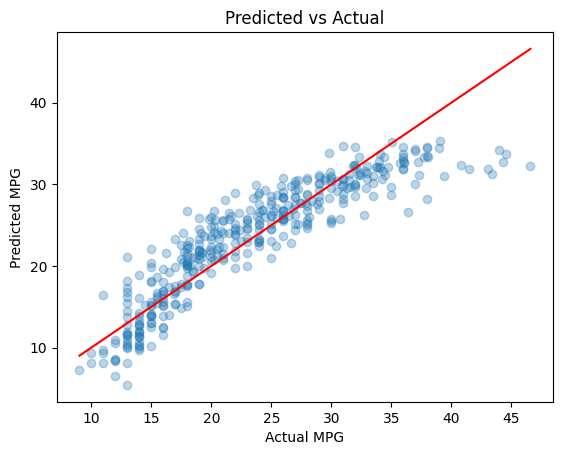

R²: 0.8092552890383932


In [8]:
predictions = np.array([np.dot(w_final, X_std[i]) + b_final for i in range(X_std.shape[0])])

plt.scatter(y, predictions, alpha=0.3)
plt.plot([y.min(), y.max()], [y.min(), y.max()], color="red")  # perfect-prediction line
plt.xlabel("Actual MPG")
plt.ylabel("Predicted MPG")
plt.title("Predicted vs Actual")
plt.show()

print("R²:", r2_score(y, predictions))

Wait, I thought I was done here, but it seems that the data points curve away from the line and it is not lienar, so we have to fix this. The R^2 of 0.81 is decent but making this line non linear seems like it will make our line better. my inital instinct right now is to use square root as thats how the line looks like.

In [9]:
# sqrt target
y_sqrt = np.sqrt(y)
w_sqrt, b_sqrt, cost_sqrt = gradient_descent_algo(X_std, y_sqrt, w_init, 0, 0.3, 3000)
predictions_sqrt = np.array([np.dot(w_sqrt, X_std[i]) + b_sqrt for i in range(X_std.shape[0])]) ** 2

print("R² sqrt:    ", r2_score(y, predictions_sqrt))

R² sqrt:     0.8351379007234272


R² sqrt:     0.8351379007234272


Thats even better
The R^2 improves, but not like a lot, I will now try log, as that is my next instinct.

In [10]:
y_log = np.log(y)
w_log, b_log, cost_log = gradient_descent_algo(X_std, y_log, w_init, 0, 0.03, 3000)
predictions_log = np.exp(np.array([np.dot(w_log, X_std[i]) + b_log for i in range(X_std.shape[0])]))

print("R² log:     ", r2_score(y, predictions_log))

R² log:      0.8503000816985969


R² log:      0.8503000816985969


Thats even better, I wonder if i can get any better than that. Lets use sci-kit learn to figure that out for us.

In [11]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)
X = df[["cylinders", "displacement", "horsepower", "weight", "acceleration", "model year"]].to_numpy()
X_poly = poly.fit_transform(X)  # use original X before standardizing
X_poly_std = (X_poly - X_poly.mean(axis=0)) / X_poly.std(axis=0)

w_init_poly = np.zeros(X_poly_std.shape[1])
w_poly, b_poly, cost_poly = gradient_descent_algo(X_poly_std, y_log, w_init_poly, 0, 0.05, 3000)
predictions_poly = np.exp(np.array([np.dot(w_poly, X_poly_std[i]) + b_poly for i in range(X_poly_std.shape[0])]))

print("R² poly degree 2 + log:", r2_score(y, predictions_poly))

R² poly degree 2 + log: 0.8772659567273384


Using scikit-learn and my own manual functions, we got the best so far, lets use scikit-learn fully now to see what the best possible is

sklearn poly + log R²: 0.8864580435122956


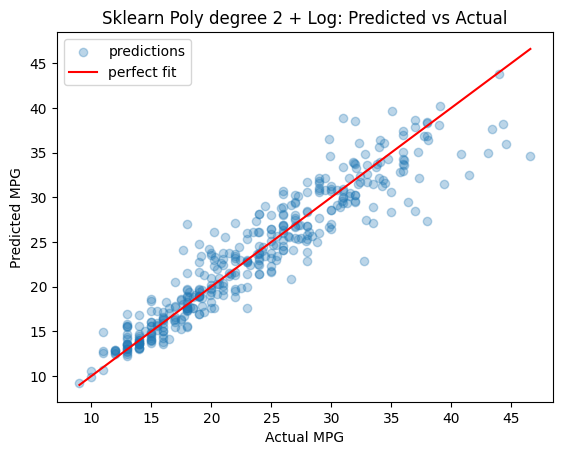

In [12]:
model_poly_sk = LinearRegression()
model_poly_sk.fit(X_poly_std, y_log)
predictions_poly_sk = np.exp(model_poly_sk.predict(X_poly_std))
print("sklearn poly + log R²:", r2_score(y, predictions_poly_sk))

# scatter with sklearn line
sorted_idx = np.argsort(y)
plt.scatter(y, predictions_poly_sk, alpha=0.3, label="predictions")
plt.plot([y.min(), y.max()], [y.min(), y.max()], color="red", label="perfect fit")
plt.xlabel("Actual MPG")
plt.ylabel("Predicted MPG")
plt.title("Sklearn Poly degree 2 + Log: Predicted vs Actual")
plt.legend()
plt.show()

We got a new best of 0.89, the most accurate model so far, for real world practiceal use, we should always use scikit learn.

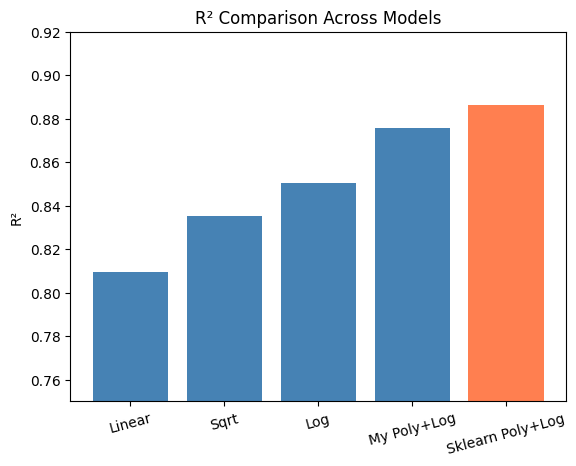

In [13]:
results = {
    "Linear": 0.8093,
    "Sqrt": 0.8351,
    "Log": 0.8503,
    "My Poly+Log": 0.8758,
    "Sklearn Poly+Log": 0.8864
}

plt.bar(results.keys(), results.values(), color=["steelblue","steelblue","steelblue","steelblue","coral"])
plt.ylim(0.75, 0.92)
plt.ylabel("R²")
plt.title("R² Comparison Across Models")
plt.xticks(rotation=15)
plt.show()

## Conclusion

In this notebook, I built a linear regression model from scratch using NumPy to predict 
fuel efficiency (MPG) from car attributes. Starting with a baseline R² of 0.81, I 
experimented with three target transformations and polynomial features:

- A sqrt transform on the target improved R² to 0.84
- A log transform improved it further to 0.85, confirming that MPG has a diminishing 
  relationship with features like weight and displacement
- Adding degree-2 polynomial features on top of the log transform pushed my from-scratch 
  model to 0.876, and sklearn's optimized solver reached 0.886

The gap between my gradient descent (0.876) and sklearn (0.886) is due to 3000 iterations 
not being enough to fully converge, as more iterations or a higher learning rate would close it.

The key insight from this dataset is that raw linear regression on raw features undersells 
the data. A simple log transform + squared features built entirely with NumPy and 
a handwritten gradient descent loop gets within 1% of sklearn's best result.